In [3]:
import numpy as np
import os

import webdataset as wds
import io
from skimage import morphology, measure


def quick_white_matter_mask(brain_volume):
    """
    brain_volume: A 3D or 2D NumPy array of a skull-stripped T1 MRI.
    Returns a binary mask of the brightest tissue (assumed to be White Matter).
    """
    # 1. Flatten the image and remove background (0 intensity)
    pixels = brain_volume.flatten()
    brain_pixels = pixels[pixels > 0.05] # Adjust threshold if background is noisy

    if len(brain_pixels) == 0:
        return np.zeros_like(brain_volume, dtype=np.float32)

    # 2. Find the intensity threshold for the top ~30% brightest pixels
    # (White matter roughly makes up the top intensity band in a T1)
    # This is a fast, statistical hack instead of formal clustering
    threshold = np.quantile(brain_pixels, 0.7)

    # 3. Create the binary mask
    wm_mask = (brain_volume > threshold).astype(np.float32)

    return wm_mask

def slice_by_slice_white_matter_mask(brain_volume):
    """
    brain_volume: A 3D NumPy array (Num_Images, Height, Width).
    Returns a binary mask calculated image-by-image.
    """
    # Create an empty volume to store our final masks
    wm_mask_volume = np.zeros_like(brain_volume, dtype=np.float32)

    # Loop through each image/slice in the volume (axis 0)
    for i in range(brain_volume.shape[0]):
        single_image = brain_volume[i]

        # 1. Isolate the brain pixels for THIS specific image
        pixels = single_image.flatten()
        brain_pixels = pixels[pixels > 0.05]

        # If the image is just empty background, skip it
        if len(brain_pixels) == 0:
            continue

        # 2. Find the threshold for THIS specific image
        # (Using 0.55 here gives you the threshold for the TOP 45% brightest pixels)
        threshold = np.quantile(brain_pixels, 0.55)

        # 3. Create the binary mask and store it in our final volume
        wm_mask_volume[i] = (single_image > threshold).astype(np.float32)

    return wm_mask_volume

In [4]:
def isolate_brain_from_numpy(wm_mask: np.ndarray, erosion_radius: int = 3) -> np.ndarray:
    """
    Takes a NumPy binary mask containing a brain and a skull,
    removes the skull, and returns the cleaned NumPy array.
    """
    is_3d = (wm_mask.ndim == 3)

    # Squeeze out channel dimension if it exists and ensure boolean
    mask_np = wm_mask.squeeze() > 0

    if not mask_np.any():
        return np.zeros_like(wm_mask)

    # 1. Erosion
    selem = morphology.disk(erosion_radius)
    eroded = morphology.binary_erosion(mask_np, selem)

    # 2. Connected Components
    labels = measure.label(eroded, background=0)

    if labels.max() == 0:
        return np.zeros_like(wm_mask)

    # 3. Find the largest component (The Brain)
    counts = np.bincount(labels.ravel())
    counts[0] = 0
    largest_label = counts.argmax()

    brain_eroded = (labels == largest_label)

    # 4. Dilation
    brain_dilated = morphology.binary_dilation(brain_eroded, selem)

    # 5. Logical AND
    final_mask_np = brain_dilated & mask_np

    # Restore channel dimension if the original had it
    if is_3d:
        final_mask_np = np.expand_dims(final_mask_np, axis=0)

    # Return matching the original data type (e.g., float32 or uint8)
    return final_mask_np.astype(wm_mask.dtype)

# Training Dataset

In [5]:
train_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_train.npy"

bg_array = np.load(train_bg_path, mmap_mode='r')
# bg_array = bg_array[:, :, :, 0]
print(bg_array.shape)

wm_mask = slice_by_slice_white_matter_mask(bg_array)

(171592, 260, 311, 1)


In [11]:
i = 1

wm_array = wm_mask[i, :, :, 0]
image_array = bg_array[i, :, :, 0] #  (your 280x320 array)

mask_array = isolate_brain_from_numpy(wm_array)

# Extract valid coordinates
valid_x, valid_y = np.where(mask_array > 0)

# Stack them into a shape of (N, 2) and cast to int16 to save maximum space
if len(valid_y) > 0:
    valid_coords = np.column_stack((valid_y, valid_x)).astype(np.int16)
else:
    # Fallback for an empty mask
    valid_coords = np.array([[170, 220]], dtype=np.int16)

In [15]:
save_path = '/shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/'

os.makedirs(save_path, exist_ok=True)

pattern = os.path.join(save_path, "dataset-%06d.tar")

# 2. Maximum number of items per shard (1000 is a good default)
maxcount = 2000
maxsize = 1e10

with wds.ShardWriter(pattern, maxcount=maxcount, maxsize=maxsize) as sink:
    for i in range(bg_array.shape[0]):
        wm_array = wm_mask[i, :, :, 0]
        image_array = bg_array[i, :, :, 0] #  (your 280x320 array)

        mask_array = isolate_brain_from_numpy(wm_array)

        # Extract valid coordinates
        valid_x, valid_y = np.where(mask_array > 0)

        # Stack them into a shape of (N, 2) and cast to int16 to save maximum space
        if len(valid_y) > 0:
            valid_coords = np.column_stack((valid_x, valid_y)).astype(np.int16)
        else:
            # Fallback for an empty mask
            valid_coords = np.array([[170, 220]], dtype=np.int16)

        # if len(valid_x) > 0:
        #         # Pick one random index from the valid coordinates
        #         rand_idx = np.random.randint(0, len(valid_x))
        #         x0 = int(valid_x[rand_idx])
        #         y0 = int(valid_y[rand_idx])
        # else:
        #     print(f'no mask found at {i}-th image')
        #     x0, y0 = 170, 220

        # label = ... (your integer label)

        img_byte_arr = io.BytesIO()
        np.save(img_byte_arr, image_array)
        img_bytes = img_byte_arr.getvalue()

        # mask_byte_arr = io.BytesIO()
        # np.save(mask_byte_arr, mask_array)
        # mask_bytes = mask_byte_arr.getvalue()

        coords_byte_arr = io.BytesIO()
        np.save(coords_byte_arr, valid_coords)
        coords_bytes = coords_byte_arr.getvalue()

        # 2. Update your sample dictionary to use the "npy" extension
        sample = {
                    "__key__": f"sample_{i:06d}",
                    "image.npy": img_bytes,
                    "coords.npy": coords_bytes,
                    # "mask.npy": mask_bytes,   # Note the custom name ending in .npy
                    # "json": {"y0": y0, "x0": x0}  # WebDataset automatically handles this!
                }

        # 5. Write the sample to the current shard
        sink.write(sample)

print("Finished writing all shards!")

# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000000.tar 0 0.0 GB 0
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000001.tar 2000 0.8 GB 2000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000002.tar 2000 0.8 GB 4000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000003.tar 2000 0.8 GB 6000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000004.tar 2000 0.8 GB 8000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000005.tar 2000 0.8 GB 10000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000006.tar 2000 0.8 GB 12000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000007.tar 2000 0.8 GB 14000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks_mask/dataset-000008.tar 2000 0.8 GB 16000
# writing /shared/ana

In [4]:
# save_path = '/shared/anastasio-s2/SI/HCP_selected/background/train_sks/'
#
# os.makedirs(save_path, exist_ok=True)
#
# pattern = os.path.join(save_path, "dataset-%06d.tar")
#
# # 2. Maximum number of items per shard (1000 is a good default)
# maxcount = 2000
# maxsize = 1e10
#
# with wds.ShardWriter(pattern, maxcount=maxcount, maxsize=maxsize) as sink:
#     for i in range(bg_array.shape[0]):
#         wm_array = wm_mask[i]
#
#         final_mask = isolate_brain_from_numpy(wm_array)
#
#         valid_x, valid_y = np.where(final_mask > 0)
#
#         if len(valid_x) > 0:
#                 # Pick one random index from the valid coordinates
#                 rand_idx = np.random.randint(0, len(valid_x))
#                 x0 = int(valid_x[rand_idx])
#                 y0 = int(valid_y[rand_idx])
#         else:
#             print(f'no mask found at {i}-th image')
#             x0, y0 = 170, 220
#
#         image_array = bg_array[i] #  (your 280x320 array)
#         # label = ... (your integer label)
#
#         npy_byte_arr = io.BytesIO()
#         np.save(npy_byte_arr, image_array)
#         npy_bytes = npy_byte_arr.getvalue()
#
#         # 2. Update your sample dictionary to use the "npy" extension
#         sample = {
#                     "__key__": f"sample_{i:06d}",
#                     "npy": npy_bytes,
#                     "json": {"y0": y0, "x0": x0}  # WebDataset automatically handles this!
#                 }
#
#         # 5. Write the sample to the current shard
#         sink.write(sample)
#
# print("Finished writing all shards!")

# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000000.tar 0 0.0 GB 0
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000001.tar 2000 0.6 GB 2000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000002.tar 2000 0.6 GB 4000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000003.tar 2000 0.6 GB 6000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000004.tar 2000 0.6 GB 8000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000005.tar 2000 0.6 GB 10000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000006.tar 2000 0.6 GB 12000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000007.tar 2000 0.6 GB 14000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000008.tar 2000 0.6 GB 16000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train_sk

# Valid and Test Dataset

In [38]:
test_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_test.npy"
bg_test_array = np.load(test_bg_path, mmap_mode='r')

bg_val_array = bg_test_array[:5000, :, :, 0]
# bg_test_array = bg_test_array[5000:, :, :, 0]
# bg_val_array = bg_test_array

wm_mask = slice_by_slice_white_matter_mask(bg_val_array)

In [53]:
bg_val_interleaved_array = np.repeat(bg_val_array, repeats=2, axis=0)

B, H, W = bg_val_interleaved_array.shape
target_size = 272, 320
half_B = B // 2

sigma = 3.0
amplitude = 0.15
noise_level = 45.0

data_name = f'sks_{sigma}_{amplitude}_{noise_level}'

X, Y = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

In [54]:
for i in range(wm_mask.shape[0]):
    wm_array = wm_mask[i]

    final_mask = isolate_brain_from_numpy(wm_array)

    valid_x, valid_y = np.where(final_mask > 0)

    if len(valid_x) > 0:
            # Pick one random index from the valid coordinates
            rand_idx = np.random.randint(0, len(valid_x))
            x0 = int(valid_x[rand_idx])
            y0 = int(valid_y[rand_idx])
    else:
        print(f'no mask found at {i}-th image')
        x0, y0 = 170, 220

    # distance = np.sqrt((X - x0) ** 2 + (Y - y0) ** 2)
    # within_3sigma = distance <= 3 * sigma
    #
    # signal = np.zeros((H, W), dtype=np.float32)
    # signal[within_3sigma] = amplitude * np.exp(-0.5 * ((X[within_3sigma] - x0) ** 2 + (Y[within_3sigma] - y0) ** 2) / (sigma ** 2))
    distance_sq = (X - x0) ** 2 + (Y - y0) ** 2
    within_3sigma = distance_sq <= (3 * sigma) ** 2

    gaussian = amplitude * np.exp(-0.5 * distance_sq / (sigma ** 2))
    signal = np.where(within_3sigma, gaussian, np.zeros_like(gaussian))

    bg_val_interleaved_array[2 * i + 1] += signal

In [55]:
target_H, target_W = target_size
pad_h = target_H - H
pad_w = target_W - W

numpy_pad_tuple = (
    (0, 0),                                            # Axis 0: Channels (no padding)
    (max(0, pad_h // 2), max(0, pad_h - pad_h // 2)),  # Axis 1: Height (top, bottom)
    (max(0, pad_w // 2), max(0, pad_w - pad_w // 2))   # Axis 2: Width (left, right)
)

bg_val_interleaved_array = np.pad(bg_val_interleaved_array, pad_width=numpy_pad_tuple, mode='constant', constant_values=0.0)

In [56]:
from numpy.fft import fft2, ifft2


def apply_kspace_noise(imgs, mask, noise_level):
    """
    Applies complex noise in the k-space (frequency domain) to a batch of images.
    Expects imgs shape: (B, H, W) or (B, C, H, W)
    """
    # Perform batched 2D FFT
    kspace = fft2(imgs)

    # Generate batched complex noisea
    noise_real = np.random.normal(0, noise_level, size=kspace.shape)
    noise_imag = np.random.normal(0, noise_level, size=kspace.shape)
    noise = noise_real + 1j * noise_imag

    # Add noise and apply mask
    if mask is not None:
        kspace_noisy = (kspace + noise) * mask
    else:
        kspace_noisy = kspace + noise

    # Perform batched 2D Inverse FFT
    img_recon = ifft2(kspace_noisy)

    return np.real(img_recon)

feats = np.zeros_like((bg_val_interleaved_array), dtype=np.float32)

for i in range(B):
    feats[i] = apply_kspace_noise(bg_val_interleaved_array[i], None, noise_level)

labels = np.tile([0, 1], 5000)

79 227


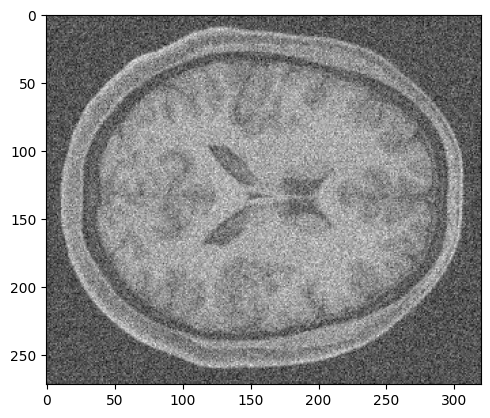

In [57]:
import matplotlib.pyplot as plt

print(x0, y0)

plt.imshow(feats[9998], cmap='gray')

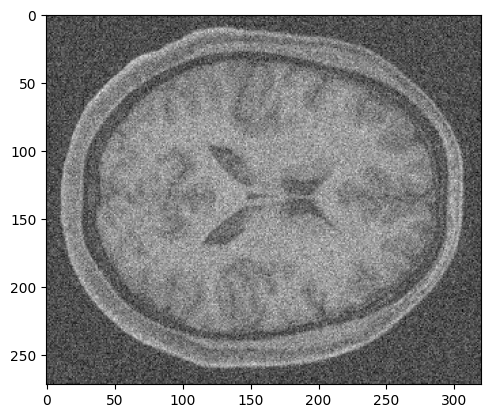

In [58]:
plt.imshow(feats[9999], cmap='gray')

In [59]:
import os

import webdataset as wds
import io

save_path = f'/shared/anastasio-s2/SI/HCP_selected/background/val/{data_name}'
# save_path = f'/shared/anastasio-s2/SI/HCP_selected/background/test/{data_name}'

os.makedirs(save_path, exist_ok=True)

pattern = os.path.join(save_path, "dataset-%06d.tar")

# 2. Maximum number of items per shard (1000 is a good default)
maxcount = 2000
maxsize = 1e10

with wds.ShardWriter(pattern, maxcount=maxcount, maxsize=maxsize) as sink:
    for i in range(bg_val_interleaved_array.shape[0]):

        image_array = feats[i] #  (your 280x320 array)
        label = labels[i]

        npy_byte_arr = io.BytesIO()
        np.save(npy_byte_arr, image_array)
        npy_bytes = npy_byte_arr.getvalue()

        # 2. Update your sample dictionary to use the "npy" extension
        sample = {
                    "__key__": f"sample_{i:06d}",
                    "npy": npy_bytes,
                    "cls": str(label).encode('utf-8'),
        }

        # 5. Write the sample to the current shard
        sink.write(sample)

print("Finished writing all shards!")

# writing /shared/anastasio-s2/SI/HCP_selected/background/val/sks_3.0_0.15_45.0/dataset-000000.tar 0 0.0 GB 0
# writing /shared/anastasio-s2/SI/HCP_selected/background/val/sks_3.0_0.15_45.0/dataset-000001.tar 2000 0.7 GB 2000
# writing /shared/anastasio-s2/SI/HCP_selected/background/val/sks_3.0_0.15_45.0/dataset-000002.tar 2000 0.7 GB 4000
# writing /shared/anastasio-s2/SI/HCP_selected/background/val/sks_3.0_0.15_45.0/dataset-000003.tar 2000 0.7 GB 6000
# writing /shared/anastasio-s2/SI/HCP_selected/background/val/sks_3.0_0.15_45.0/dataset-000004.tar 2000 0.7 GB 8000
Finished writing all shards!


# Dataset Check

In [62]:
url = "/shared/anastasio-s2/SI/HCP_selected/background/train_sks/dataset-000085.tar"

train_dataset = (
    wds.WebDataset(url, shardshuffle=False)
    # .shuffle(10000, initial=10000)
    .decode("torch")
    # Tell WebDataset to output the image AND the JSON dictionary
    .to_tuple("npy", "json")
    .batched(100)
)

from torch.utils.data import DataLoader

dataloader = DataLoader(train_dataset, num_workers=1, batch_size=None)

In [63]:
import torch

iters = iter(dataloader)
data = next(iters)

images = data[0].to('cuda')

B, H, W = images.shape
half_B = B // 2

# ---------------------------------------------------------
# STEP A: Create and Add Signal to the FIRST HALF
# (Do this before padding so your y0, x0 coordinates stay accurate to the anatomy!)
# ---------------------------------------------------------

# Inject the localized signal into the first half of the batch
X, Y = torch.meshgrid(
    torch.arange(H, dtype=torch.float32, device='cuda'),
    torch.arange(W, dtype=torch.float32, device='cuda'),
    indexing='ij'
)

x0 = torch.tensor([meta["x0"] for meta in data[1][:half_B]], device='cuda', dtype=torch.float32)
y0 = torch.tensor([meta["y0"] for meta in data[1][:half_B]], device='cuda', dtype=torch.float32)

x0 = x0.view(half_B, 1, 1)
y0 = y0.view(half_B, 1, 1)

distance_sq = (X - x0) ** 2 + (Y - y0) ** 2
within_3sigma = distance_sq <= (3 * sigma) ** 2

# 4. Generate the Gaussian signal for the entire half-batch
gaussian = amplitude * torch.exp(-0.5 * distance_sq / (sigma ** 2))

# 5. Mask out everything outside 3 sigma (Create the final half_B, H, W signal)
# torch.where is a very clean way to apply this mask dynamically
signal = torch.where(within_3sigma, gaussian, torch.zeros_like(gaussian))

# signal = torch.zeros((H, W), dtype=torch.float32, device='cuda')
# signal[within_3sigma] = amplitude * torch.exp(-0.5 * distance_sq[within_3sigma] / (sigma ** 2))

images[:half_B] = images[:half_B] + signal

In [59]:
len(data[1])

100

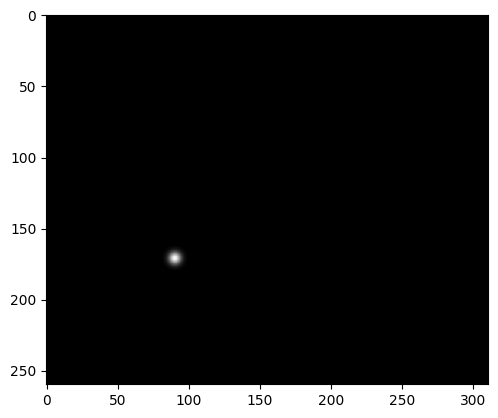

In [49]:
plt.imshow(signal[6].cpu(), cmap='gray')

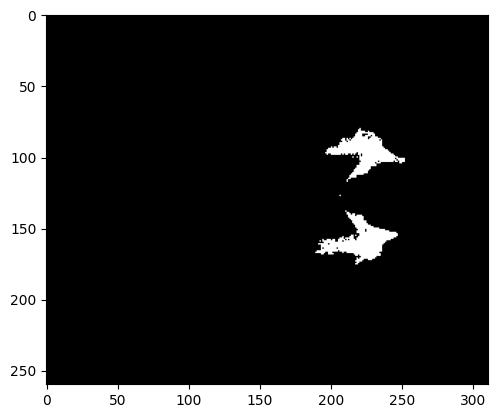

In [216]:
# heatmap_map = np.sum(wm_mask_brain_all > 0, axis=0)
#
# intersection_map = np.all(wm_mask_brain_all > 0, axis=0)

# plt.imshow(intersection_map, cmap='gray')